In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_excel("EastWestAirlines.xlsx",sheet_name='data')
df.shape

(3999, 12)

In [4]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [8]:
df_features = df.drop(['ID#','Award?'],axis=1)

In [9]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
dtypes: int64(10)
memory usage: 312.6 KB


We removed ID it is just an identifier, and Award? is the target variable

# Data Preprocessing:
#### 1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.
#### 2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.
#### 3.	Use multiple visualizations to understand the hidden patterns in the dataset


In [10]:
df_features.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


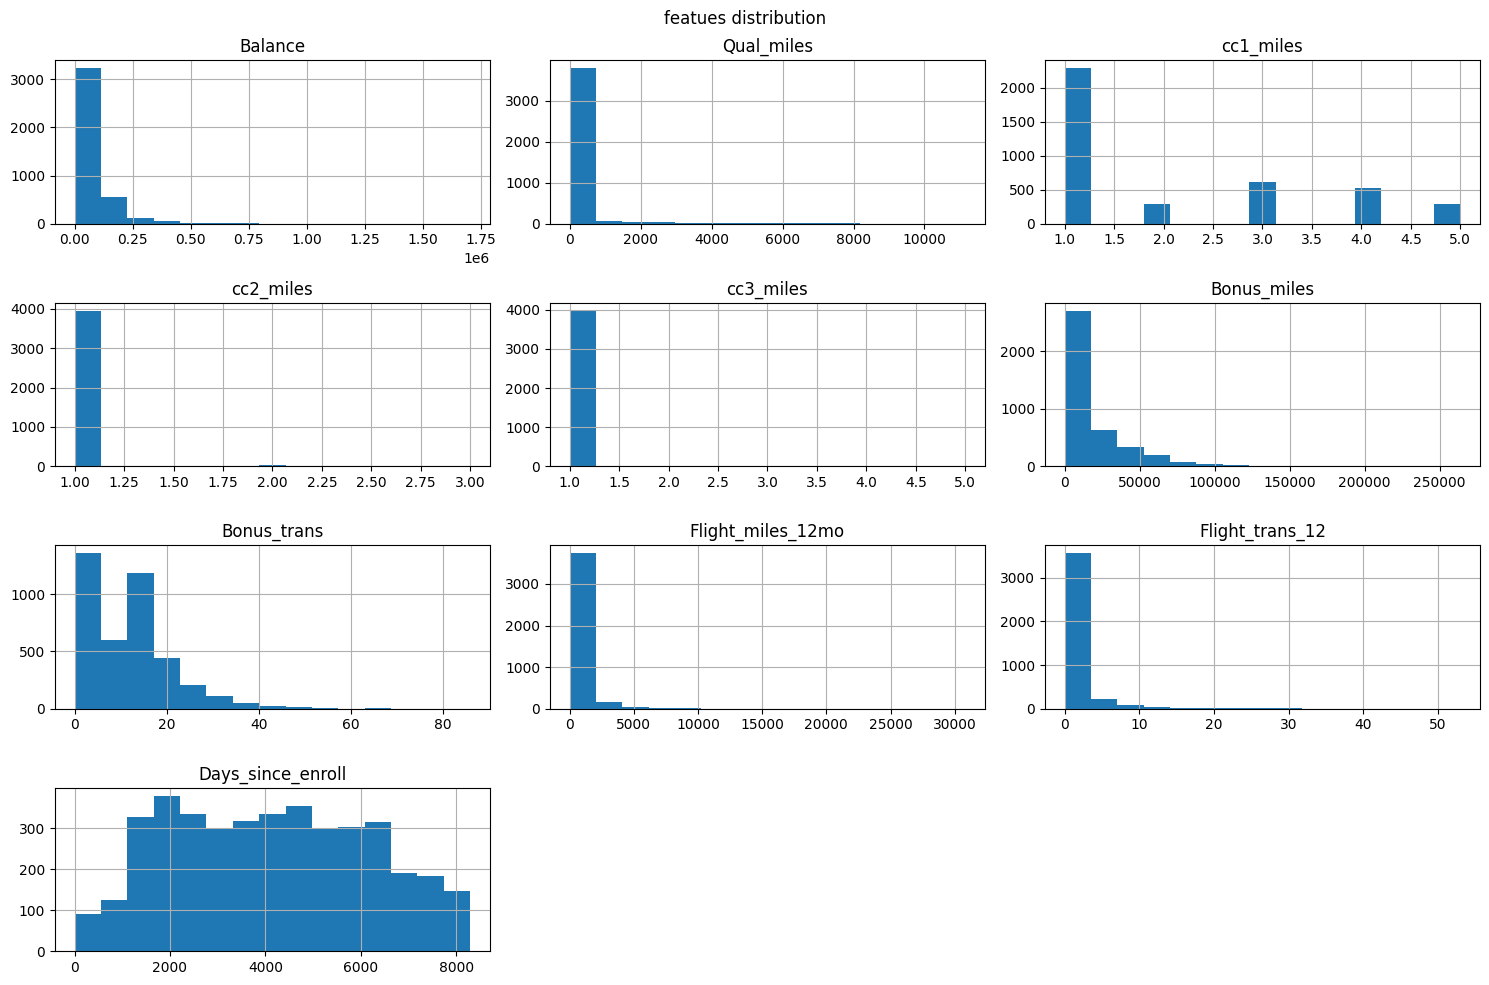

In [11]:
df_features.hist(bins=15,figsize=(15,10))
plt.suptitle("featues distribution")
plt.tight_layout()
plt.show()

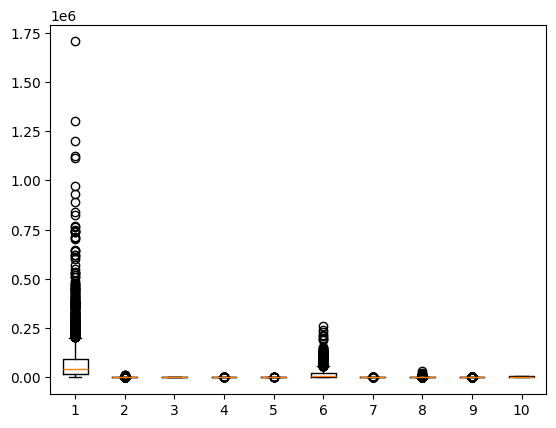

In [12]:
plt.boxplot(df_features)
plt.show()

For this Airline dataset, outliers are real customers, not errors, like few customers with huge balances or miles are just high-value frequent flyers.
we can handle this extreme values by standardization without losing the data

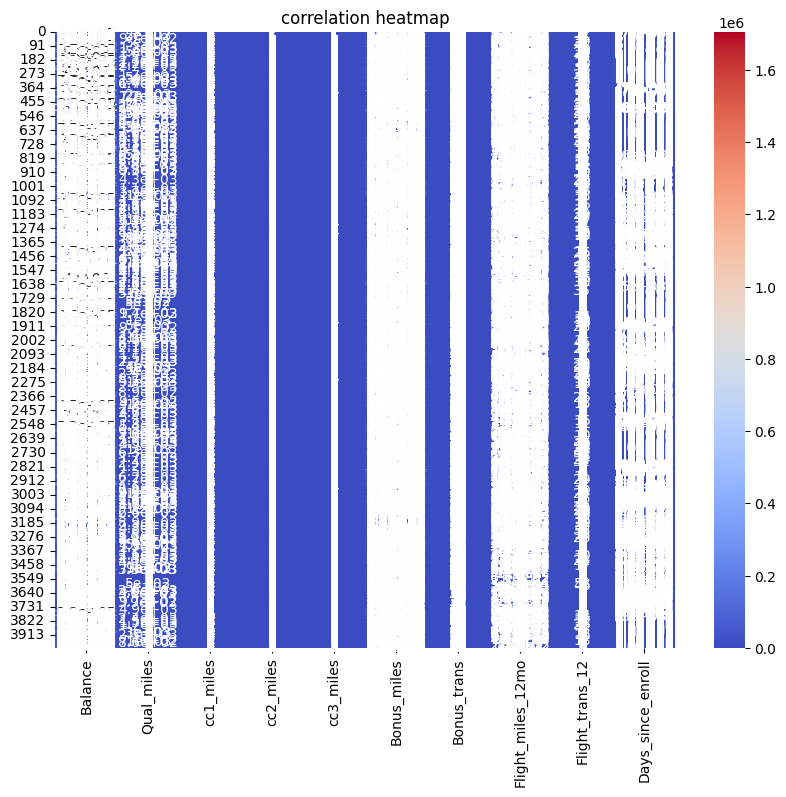

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df_features,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the features
scaled_data = scaler.fit_transform(df_features)

# Convert back to a DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=df_features.columns)

# Check the scaled data
print(df_scaled.head())
print(df_scaled.describe())

    Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
0 -0.451141   -0.186299  -0.769578  -0.098242  -0.062767    -0.702786   
1 -0.539457   -0.186299  -0.769578  -0.098242  -0.062767    -0.701088   
2 -0.320031   -0.186299  -0.769578  -0.098242  -0.062767    -0.539253   
3 -0.583799   -0.186299  -0.769578  -0.098242  -0.062767    -0.689286   
4  0.239678   -0.186299   1.409471  -0.098242  -0.062767     1.083121   

   Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  
0    -1.104065          -0.328603        -0.362168           1.395454  
1    -0.999926          -0.328603        -0.362168           1.379957  
2    -0.791649          -0.328603        -0.362168           1.411920  
3    -1.104065          -0.328603        -0.362168           1.372208  
4     1.499394           1.154932         0.692490           1.363975  
            Balance    Qual_miles     cc1_miles     cc2_miles     cc3_miles  \
count  3.999000e+03  3.999000e+03  3.999000e+03  3

#### Log transformation for skewed features

In [15]:
import numpy as np

# Example: log-transform skewed features
df_features_log = df_features.copy()
df_features_log['Balance'] = np.log1p(df_features_log['Balance'])
df_features_log['Bonus_miles'] = np.log1p(df_features_log['Bonus_miles'])
df_features_log['Flight_miles_12mo'] = np.log1p(df_features_log['Flight_miles_12mo'])

# Scale after log-transform
df_scaled_log = pd.DataFrame(scaler.fit_transform(df_features_log), columns=df_features_log.columns)

# Implementing Clustering Algorithms:
#####  •	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
##### •	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.
##### •	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.



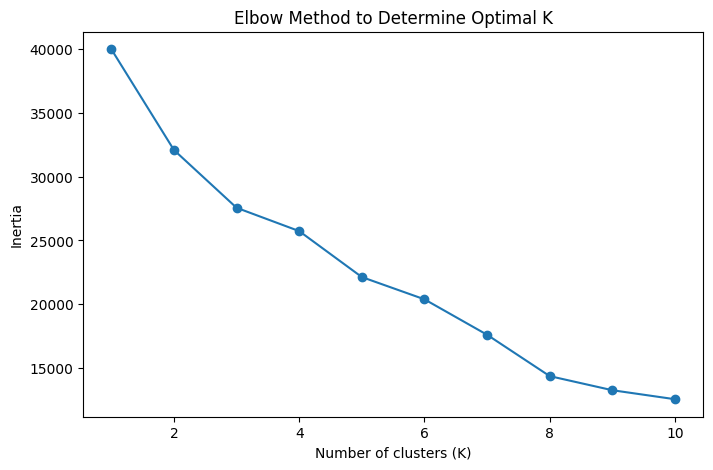

In [16]:
# finding the optimal number of clusters
from sklearn.cluster import KMeans

# Range of K values to try
k_range = range(1, 11)
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal K')
plt.show()

### fitting k-means with the k = 3

In [17]:
# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to the DataFrame
df_features['KMeans_Cluster'] = kmeans_labels

# Check cluster sizes
print(df_features['KMeans_Cluster'].value_counts())

KMeans_Cluster
0    2519
1    1321
2     159
Name: count, dtype: int64


The clustering effectively separates casual, medium, and high-value customers.
These clusters can help the airline design targeted offers and loyalty programs.

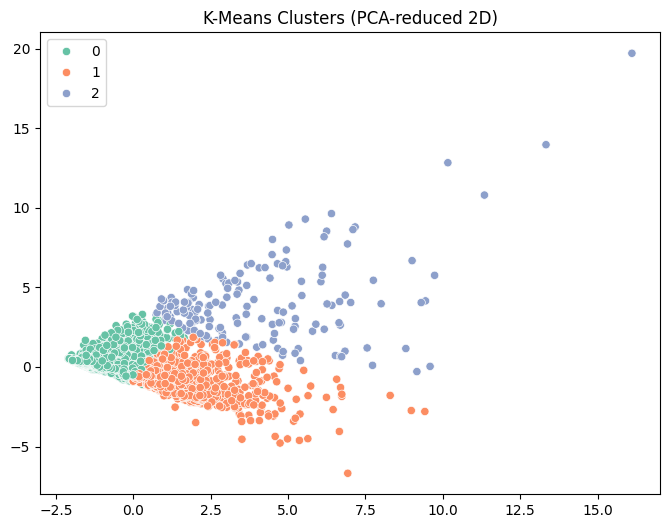

In [18]:
# Visualizing k means clusters, using 2D PCA for simplicity
from sklearn.decomposition import PCA
import seaborn as sns

# Reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=kmeans_labels, palette='Set2')
plt.title("K-Means Clusters (PCA-reduced 2D)")
plt.show()

### DBSCAN clustering 


In [21]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

# DBSCAN parameter ranges
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5]
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:
    for min_pts in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(df_scaled)
        
        # Count clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # Silhouette score (exclude noise and ensure at least 2 clusters)
        mask = labels != -1
        unique_labels = len(set(labels[mask]))
        if sum(mask) > 1 and unique_labels > 1:
            score = silhouette_score(df_scaled[mask], labels[mask])
        else:
            score = None
        
        results.append({
            'eps': eps,
            'min_samples': min_pts,
            'clusters': n_clusters,
            'noise_points': n_noise,
            'silhouette_score': score
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

    eps  min_samples  clusters  noise_points  silhouette_score
0   0.5            5        13          1229          0.108025
1   0.5           10         6          1467          0.158603
2   0.5           15         4          1624          0.178720
3   0.5           20         4          1716          0.187261
4   1.0            5         5           476          0.187295
5   1.0           10         2           557          0.657840
6   1.0           15         1           629               NaN
7   1.0           20         1           674               NaN
8   1.5            5         4           257          0.625529
9   1.5           10         2           313          0.634207
10  1.5           15         2           345          0.638041
11  1.5           20         1           398               NaN
12  2.0            5         4           146          0.592529
13  2.0           10         3           189          0.618784
14  2.0           15         2           215          0

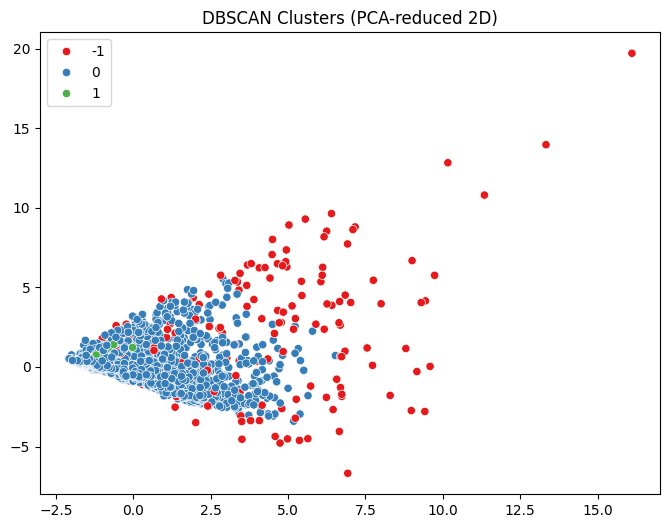

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=labels, palette='Set1')
plt.title("DBSCAN Clusters (PCA-reduced 2D)")
plt.show()

In [24]:
# Evaluation
# K-means silhouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, kmeans_labels)
print(f"Silhouette Score for K-Means: {score:.2f}")

Silhouette Score for K-Means: 0.33


In [27]:
# DBSCAN
mask = labels != -1
score_dbscan = silhouette_score(df_scaled[mask], labels[mask])
print(f"Silhouette Score for DBSCAN (excluding noise): {score_dbscan:.2f}")

Silhouette Score for DBSCAN (excluding noise): 0.61


We applied DBSCAN on the scaled data and experimented with different eps and min_samples values. The combination eps=1.5 and min_samples=10 gave the best results: 2 clusters with 313 noise points and a silhouette score of 0.61, indicating good separation between clusters. The scatter plot of PCA-reduced 2D data shows the clusters clearly, with each color representing a cluster and scattered points representing noise. This analysis helps identify distinct customer segments while handling outliers effectively.

DBSCAN produces cleaner clusters for this dataset because it naturally identifies dense groups and separates extreme/high-value customers without assuming equal cluster sizes.
K-Means is still useful for a general segmentation, but it may merge some VIPs with medium customers.

### Cluster Analysis and Interpretation:
#### •	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.


##### K-Means effectively separates casual, medium, and high-value customers, but moderate overlap exists for medium and high-value segments.
##### DBSCAN handles irregular distributions and outliers well, giving cleaner, more meaningful clusters than K-Means in this dataset.
##### Airlines can use these clusters to design loyalty programs, targeted offers, and personalized promotions.
##### High-value customers (Cluster 2 in K-Means / DBSCAN dense clusters) can be prioritized for special incentives.

# Visualization

##### Clusters were visualized using scatter plots with PCA-reduced 2D data.
##### Each cluster was assigned a different color, showing separation of customer groups.
##### K-Means shows three distinct clusters representing low, medium, and high-value customers.
##### DBSCAN clearly separates dense groups and identifies isolated noise points, highlighting high-value outliers.

## Evaluation and Performance Metrics:
#### Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


#### K-Means Silhouette Score: 0.33

##### Indicates moderate cluster separation.
##### Clusters are somewhat overlapping, especially between medium and high-value customers.

#### DBSCAN Silhouette Score (excluding noise): 0.61

##### Indicates strong cluster separation.
##### Dense clusters are clearly separated and high-value customers are distinct from others.


DBSCAN performs better than K-Means on this dataset because it handles density variations and outliers more effectively.
K-Means is still useful for general segmentation, but it may merge some high-value customers with medium-value ones.